# Preconditioners

&nbsp;[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/themintlab/ExecutableEngineering/blob/main/chapters/linear_systems/iterative_methods/preconditioners.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.sparse import diags
from scipy.sparse.linalg import cg, gmres, splu, spilu, LinearOperator

try:
    import executable_engineering as exe
except ImportError:
    %pip install -q executable_engineering
    import executable_engineering as exe

## The Necessity of Preconditioning

While direct solvers (like $\mathbf{L}\mathbf{U}$ decomposition) are incredibly robust, iterative solvers are highly sensitive to the condition number of the matrix. For large, complex physics problems, iterative solvers often converge at a glacial pace—or fail to converge at all.

The strategy of **preconditioning** is to modify the original linear system into an algebraically equivalent system that *behaves better*. 

Given a system $\mathbf{A}\mathbf{x}=\mathbf{b}$, we multiply by a preconditioner matrix $\mathbf{P}^{-1}$ (where $\mathbf{P}^{-1} \approx \mathbf{A}^{-1}$). This acts to geometrically transform the elongated valleys into a more spherical bowl, pushing the condition number of the resulting system closer to 1.

### Matrix Application Strategies

There are three ways to apply the preconditioner $\mathbf{P}^{-1}$:

**1. Left Preconditioning (Most Common):**
$$ \mathbf{P}^{-1} \mathbf{A} \mathbf{x} = \mathbf{P}^{-1} \mathbf{b} $$

**2. Right Preconditioning:**
$$ \mathbf{A} \mathbf{P}^{-1} \mathbf{y} = \mathbf{b} \quad \text{where} \quad \mathbf{P} \mathbf{x} = \mathbf{y} $$

**3. Two-Sided Preconditioning:**
$$ \mathbf{Q} \mathbf{A} \mathbf{P}^{-1} \mathbf{y} = \mathbf{Q} \mathbf{b} \quad \text{where} \quad \mathbf{P} \mathbf{x} = \mathbf{y} $$
*(Note: Two-sided preconditioning is often required to preserve the symmetry of $\mathbf{A}$, a critical property for solvers like Conjugate Gradient).*

### The Ideal Preconditioner

The theoretically "perfect" preconditioner is $\mathbf{P} = \mathbf{A}$, which trivially solves the system in one step. However, finding $\mathbf{A}^{-1}$ explicitly defeats the entire purpose of an iterative solver! 

Furthermore, the exact inverse of a sparse matrix is almost always completely dense. Therefore, we **never** calculate or store $\mathbf{P}^{-1}$ explicitly in memory. Instead, we store $\mathbf{P}$ (or its factors) and provide the algorithm with a *method* for applying $\mathbf{P}^{-1}$ to a vector.

A high-quality preconditioner requires balancing:
* **Speed:** How fast it can be computed and applied.
* **Memory:** The degree of fill-in (sparsity) compared to $\mathbf{A}$.
* **Parallelizability:** How well it scales across compute clusters.

Let's test several common preconditioners against a physical system!

## The Test Problem: The Poisson Equation

As a working example, let's discretize a standard Poisson heat-transfer equation on a 2D unit square grid (discussed later in differential equations).

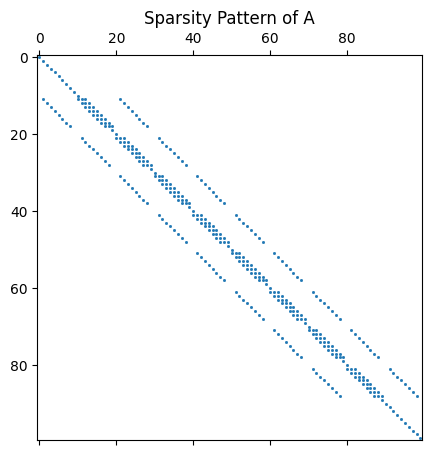

In [2]:
N = 10  # Mesh size
A, f = exe.discretise_poisson(N, 1)

plt.figure(figsize=(5,5))
plt.spy(A, markersize=1)
plt.title("Sparsity Pattern of A")
plt.show()

### 1. Jacobi (Diagonal) Preconditioning

The simplest preconditioner is the **Jacobi** preconditioner. It simply extracts the main diagonal of $\mathbf{A}$. Because it is purely diagonal, its inverse is trivially computed by taking the reciprocal of the diagonal elements, meaning it requires almost zero memory or compute overhead!

Let's apply it via `scipy.sparse.linalg.gmres` and track the residual convergence. 

In [3]:
Pinv_jacobi = diags(1/A.diagonal(), offsets=0, format='csr')

print('Unconditioned condition number :', np.linalg.cond(A.todense()))
print('Preconditioned condition number :', np.linalg.cond((Pinv_jacobi @ A).todense()))

x0 = np.zeros_like(f)

# Solve the system using GMRES without preconditioning
tracker_uncond = exe.IterationTracker(x0, A, f)
x_uncond, _ = gmres(A, f, x0=x0, callback=tracker_uncond, callback_type='pr_norm')

# Solve with Jacobi preconditioning
tracker_jacobi = exe.IterationTracker(x0, A, f)
x_cond, _ = gmres(A, f, x0=x0, M=Pinv_jacobi, callback=tracker_jacobi, callback_type='pr_norm')

# Plotly convergence
fig = go.Figure()
fig.add_trace(go.Scatter(y=tracker_uncond.residuals, mode='lines+markers', name='No preconditioning', line=dict(color='blue')))
fig.add_trace(go.Scatter(y=tracker_jacobi.residuals, mode='lines+markers', name='Jacobi Preconditioning', line=dict(color='orange')))
fig.update_layout(title='Jacobi Preconditioning', yaxis_type='log', xaxis_title='Iteration count', yaxis_title='Relative residual', template='plotly_white')
fig.show()

Unconditioned condition number : 1115.4433890393711
Preconditioned condition number : 32.30864938962057


#### Verdict on Jacobi preconditioning

Meh. The convergence curve barely budges. While cheap to apply, Jacobi is rarely powerful enough for complex PDEs.

### 2. Incomplete LU (ILU)

We know that a full $\mathbf{L}\mathbf{U}$ Decomposition solves the system exactly. **LU** decomposition preserves the *bandwidth* of the $\mathbf(A)$ matrix, but typically fills in the elements within that band.  

Let's look at the fill-in of the *exact* $\mathbf{L}$ and $\mathbf{U}$ matrices for our Poisson problem:

C:\Users\wellandm\AppData\Local\Temp\ipykernel_13168\1692688927.py:6: SparseEfficiencyWarning:

splu converted its input to CSC format



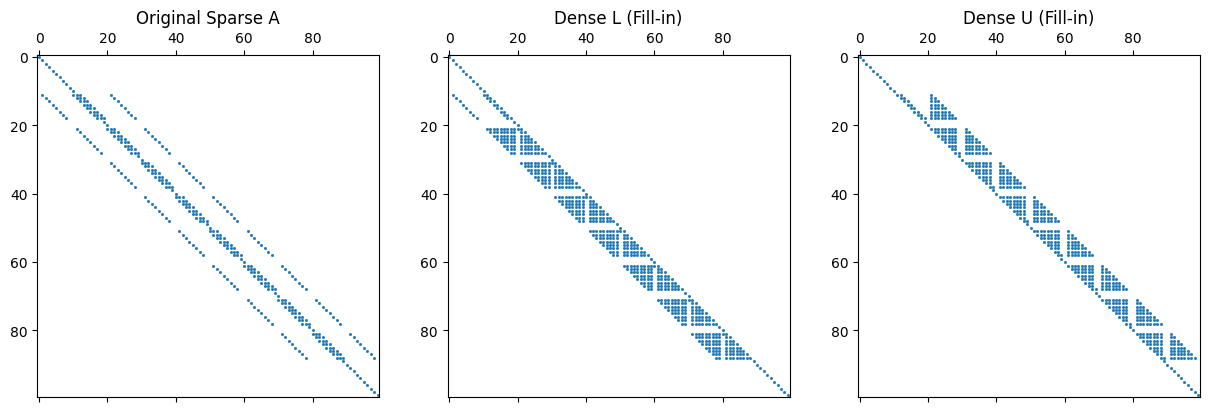

In [4]:
N = 10 # Mesh size
A, f = exe.discretise_poisson(N, 1)

# We explicitly disable column permutations (permc_spec='NATURAL') 
# and row pivoting (diag_pivot_thresh=0) to see the pure naive LU factorization!
lu = splu(A, permc_spec='NATURAL', diag_pivot_thresh=0)
L = lu.L
U = lu.U

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.spy(A, markersize=1)
ax1.set_title('Original Sparse A')
ax2.spy(L, markersize=1)
ax2.set_title('Dense L (Fill-in)')
ax3.spy(U, markersize=1)
ax3.set_title('Dense U (Fill-in)')
plt.show()

What if we calculate an *approximate* $\mathbf{L}\mathbf{U}$ decomposition that strictly limits the amount of fill-in allowed? We can use these approximate $\tilde{\mathbf{L}}$ and $\tilde{\mathbf{U}}$ factors to form a preconditioner $\mathbf{P}=\tilde{\mathbf{L}}\tilde{\mathbf{U}} \approx \mathbf{A}$. Let's use `scipy.sparse.linalg.spilu` to compute an **Incomplete LU (ILU)** factorization, explicitly capping the `fill_factor` (a measure of how many zeros originally in $\mathbf(A)$ are filled in). 

Notice that we don't pass an inverse matrix into GMRES; we pass a `LinearOperator` function that solves $\mathbf{P}\mathbf{x} = \mathbf{y}$.

In [5]:
ilu = spilu(A, drop_tol=1e-1, permc_spec='NATURAL', diag_pivot_thresh=0)

M = LinearOperator(matvec=ilu.solve, shape=(N**2, N**2), dtype=np.float64)

x0 = np.zeros_like(f)

tracker_uncond = exe.IterationTracker(x0, A, f)
x, _ = gmres(A, f, x0=x0, callback=tracker_uncond, callback_type='pr_norm', restart=200)

tracker_ilu = exe.IterationTracker(x0, A, f)
x_ilu, _ = gmres(A, f, x0=x0, M=M, callback=tracker_ilu, callback_type='pr_norm', restart=200)

fig = go.Figure()
fig.add_trace(go.Scatter(y=tracker_uncond.residuals, mode='lines', name='No preconditioning', line=dict(color='blue')))
fig.add_trace(go.Scatter(y=tracker_ilu.residuals, mode='lines', name='ILU Preconditioning', line=dict(color='green')))
fig.update_layout(title='ILU Preconditioning', yaxis_type='log', xaxis_title='Iteration count', yaxis_title='Relative residual', template='plotly_white')
fig.show()

C:\Users\wellandm\AppData\Local\Temp\ipykernel_13168\61188047.py:1: SparseEfficiencyWarning:

spilu converted its input to CSC format



Notice that we explicitly set `drop_tol=1e-1` to aggressively prune the fill-in. Let's visually compare the sparsity of our aggressively pruned Incomplete $\mathbf{L}$ matrix against the Exact $\mathbf{L}$ matrix!

C:\Users\wellandm\AppData\Local\Temp\ipykernel_13168\3544783965.py:2: SparseEfficiencyWarning:

splu converted its input to CSC format



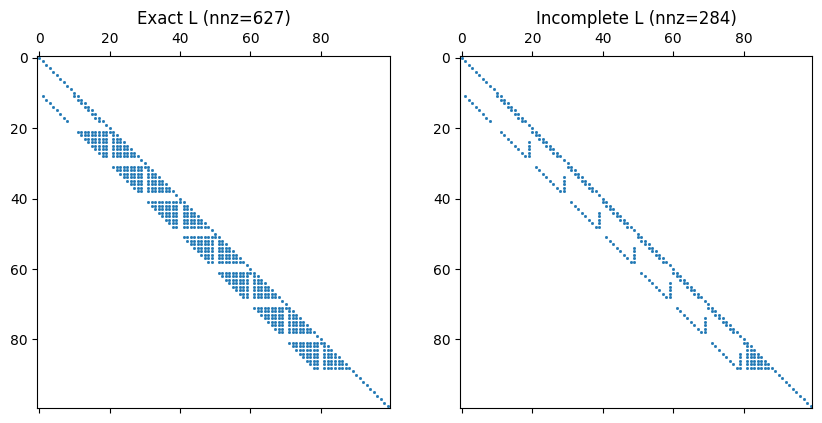

In [6]:
# Compare the sparsity of Exact LU vs our Incomplete LU
lu_exact = splu(A, permc_spec='NATURAL', diag_pivot_thresh=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.spy(lu_exact.L, markersize=1)
ax1.set_title(f"Exact L (nnz={lu_exact.L.nnz})")

ax2.spy(ilu.L, markersize=1)
ax2.set_title(f"Incomplete L (nnz={ilu.L.nnz})")
plt.show()

#### Verdict on ILU

Fantastic! The ILU preconditioner achieved lightning-fast convergence by partially solving the problem ahead of time. ILU is the standard workhorse for serial computations, though its sequential forward/backward substitutions make it notoriously difficult to parallelize.

## Preconditioners in High Performance Computing

High Performance Computing (HPC) relies on clusters of distributed nodes (thousands of CPUs) connected via a network. To solve massive physical systems, the data must be chunked across the nodes.

Because parallelizing exact direct solvers requires massive amounts of slow inter-node network communication, HPC systems rely heavily on fast iterative solvers combined with highly specialized geometric preconditioners.

### Domain Decomposition (Additive Schwarz)

**Domain Decomposition** is the most intuitive geometric approach. You literally slice the physical CAD geometry into chunks and hand each chunk to a different compute node.

Here is a finite element plane wing partitioned into colored chunks:

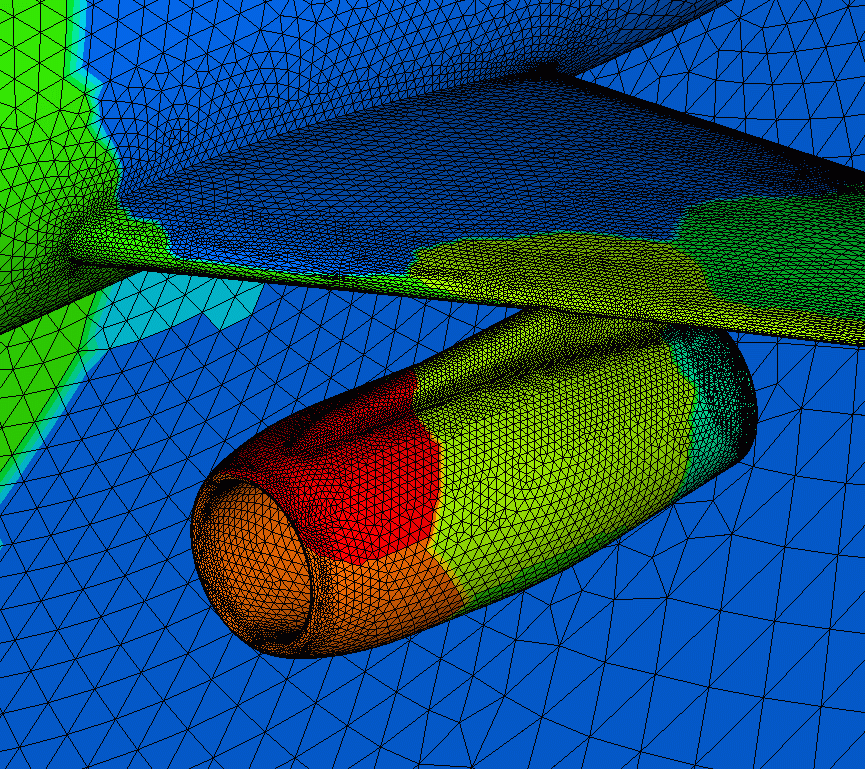

A popular variant is the **Additive Schwarz** method, which creates *overlapping* boundaries between adjacent subdomains. Each node uses a robust direct solver (like $\mathbf{L}\mathbf{U}$) on its local chunk, and the overlapping regions allow the global iterative solver to rapidly stitch the solutions together across the network.

### Multigrid Methods

**Multigrid** methods are modern, phenomenally powerful algorithms capable of achieving theoretically perfect $\mathcal{O}(n)$ scaling! 

The physical PDE is solved simultaneously on a hierarchy of meshes—from incredibly fine grids down to very coarse grids.

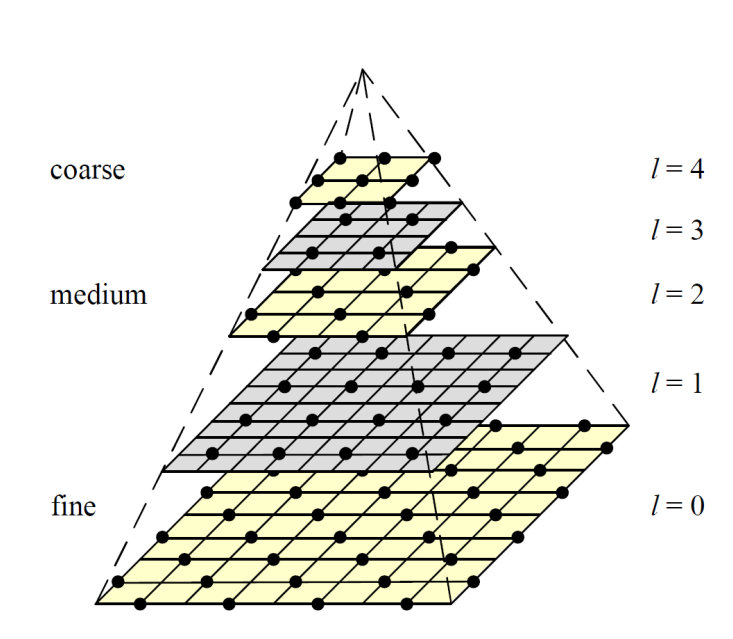

The high-resolution fine grid captures local details, but struggles to resolve global trends quickly. By projecting the residual down to the coarse grid, the solver can propagate global changes instantly. The coarse grid is often small enough to be solved entirely with a direct $\mathbf{L}\mathbf{U}$ solver, and the result is interpolated back up.

## Multiphysics Block Preconditioning

Often, physical systems involve tightly coupled equations (e.g., fluid flow interacting with structural mechanics). This produces a massive block matrix system:

$$
\begin{bmatrix}
\mathbf{A}_{fluid} & \mathbf{B}_{coupling} \\
\mathbf{C}_{coupling} & \mathbf{D}_{structure}
\end{bmatrix}
\begin{bmatrix}
\mathbf{x}_f \\
\mathbf{x}_s
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{b}_f \\
\mathbf{b}_s
\end{bmatrix}
$$

How do we precondition this block $\mathbf{A}$ matrix? One powerful approach is using the **Block Schur Complement**:

$$
\begin{bmatrix}
\mathbf{A} & \mathbf{B} \\
\mathbf{C} & \mathbf{D}
\end{bmatrix}^{-1} =
\begin{bmatrix}
\mathbf{A}^{-1} + \mathbf{A}^{-1}\mathbf{B}(\mathbf{D} - \mathbf{C}\mathbf{A}^{-1}\mathbf{B})^{-1}\mathbf{C}\mathbf{A}^{-1} & -\mathbf{A}^{-1}\mathbf{B}(\mathbf{D} - \mathbf{C}\mathbf{A}^{-1}\mathbf{B})^{-1} \\
-(\mathbf{D} - \mathbf{C}\mathbf{A}^{-1}\mathbf{B})^{-1}\mathbf{C}\mathbf{A}^{-1} & (\mathbf{D} - \mathbf{C}\mathbf{A}^{-1}\mathbf{B})^{-1}
\end{bmatrix}
$$

By mathematically isolating the highly non-linear interaction terms, solvers can apply completely different preconditioners to the fluid block vs the structure block, drastically improving convergence for complex multiphysics simulations!